Carrier transition:
P1/2 F=2 -> D3/2 F=3: frequency = x -120.000 MHz

Allowed transitions and sidebands relative to the carrier:
sideband = (target transition frequency) - (carrier frequency)

P1/2 F=1 -> D3/2 F=0: x +274.000 MHz, sideband = +394.000 MHz
P1/2 F=1 -> D3/2 F=1: x +418.000 MHz, sideband = +538.000 MHz
P1/2 F=1 -> D3/2 F=2: x +753.000 MHz, sideband = +873.000 MHz
P1/2 F=2 -> D3/2 F=1: x -1069.000 MHz, sideband = -949.000 MHz
P1/2 F=2 -> D3/2 F=2: x -734.000 MHz, sideband = -614.000 MHz
P1/2 F=2 -> D3/2 F=3: x -120.000 MHz, sideband = carrier


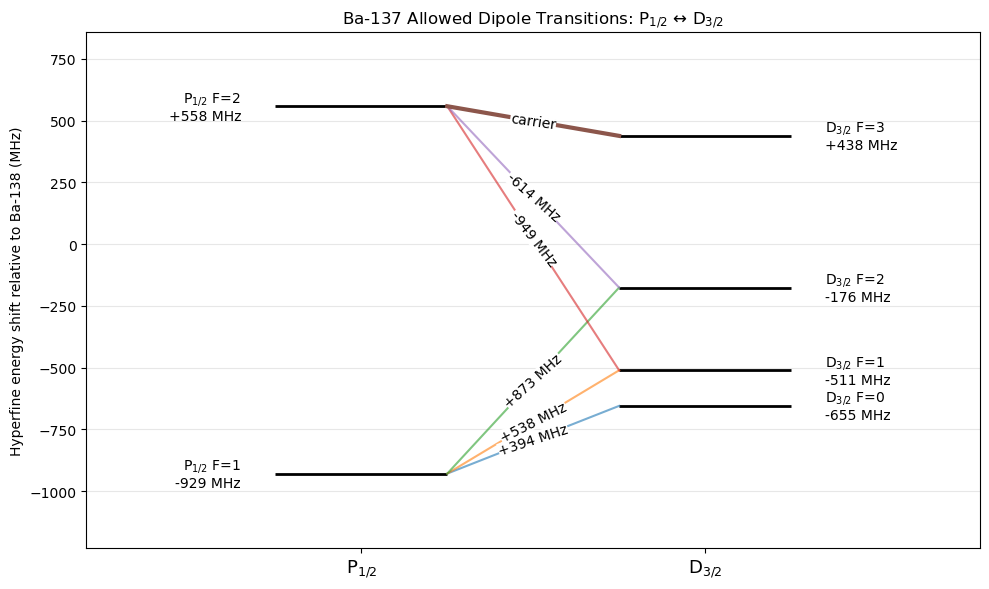

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Hyperfine energy shifts relative to Ba-138, in MHz
# --------------------------------------------------

P12 = {
    2: 558,     # P1/2 F=2
    1: -929,    # P1/2 F=1
}

D32 = {
    3: 438,      # replace these with your values
    2: -176,
    1: -511,
    0: -655,
}

# --------------------------------------------------
# Choose which allowed transition the carrier is resonant with
# Format: (P_F, D_F)
# --------------------------------------------------

carrier_transition = (2, 3)   # example: P1/2 F=2 -> D3/2 F=3

# --------------------------------------------------
# Dipole hyperfine selection rule
# ΔF = 0, ±1, but F=0 -> F=0 forbidden
# --------------------------------------------------

def is_allowed(Fp, Fd):
    if Fp == 0 and Fd == 0:
        return False
    return abs(Fd - Fp) <= 1

# --------------------------------------------------
# Helper: angle of a line in screen/display coordinates
# so text stays parallel to the plotted line
# --------------------------------------------------

def line_angle(ax, x1, y1, x2, y2):
    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    return np.degrees(np.arctan2(dy, dx))

# --------------------------------------------------
# Compute allowed transitions
# transition frequency = x + offset
# offset = E_D - E_P
# --------------------------------------------------

allowed_transitions = []

for Fp, Ep in P12.items():
    for Fd, Ed in D32.items():
        if is_allowed(Fp, Fd):
            offset = Ed - Ep
            allowed_transitions.append({
                "Fp": Fp,
                "Fd": Fd,
                "Ep": Ep,
                "Ed": Ed,
                "offset": offset,
            })

allowed_transitions.sort(key=lambda t: (t["Fp"], t["Fd"]))

# --------------------------------------------------
# Validate carrier choice
# --------------------------------------------------

carrier_Fp, carrier_Fd = carrier_transition

if carrier_Fp not in P12:
    raise ValueError(f"P1/2 F={carrier_Fp} is not defined in P12.")
if carrier_Fd not in D32:
    raise ValueError(f"D3/2 F={carrier_Fd} is not defined in D32.")
if not is_allowed(carrier_Fp, carrier_Fd):
    raise ValueError(
        f"Carrier transition P F={carrier_Fp} -> D F={carrier_Fd} "
        "is forbidden by ΔF = 0, ±1."
    )

carrier_offset = D32[carrier_Fd] - P12[carrier_Fp]

# --------------------------------------------------
# Print transition frequencies and sideband offsets
# --------------------------------------------------

print("Carrier transition:")
print(
    f"P1/2 F={carrier_Fp} -> D3/2 F={carrier_Fd}: "
    f"frequency = x {carrier_offset:+.3f} MHz"
)

print("\nAllowed transitions and sidebands relative to the carrier:")
print("sideband = (target transition frequency) - (carrier frequency)\n")

for t in allowed_transitions:
    sideband = t["offset"] - carrier_offset

    if t["Fp"] == carrier_Fp and t["Fd"] == carrier_Fd:
        sb_label = "carrier"
    else:
        sb_label = f"{sideband:+.3f} MHz"

    print(
        f"P1/2 F={t['Fp']} -> D3/2 F={t['Fd']}: "
        f"x {t['offset']:+.3f} MHz, sideband = {sb_label}"
    )

# --------------------------------------------------
# Plot hyperfine levels and allowed transitions
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x_P = 0
x_D = 1
level_width = 0.25

# Plot P1/2 levels
for F, E in sorted(P12.items(), reverse=True):
    ax.hlines(E, x_P - level_width, x_P + level_width, linewidth=2, color = 'black')
    ax.text(
        x_P - 0.35,
        E,
        f"P$_{{1/2}}$ F={F}\n{E:+.0f} MHz",
        ha="right",
        va="center",
        fontsize=10,
    )

# Plot D3/2 levels
for F, E in sorted(D32.items(), reverse=True):
    ax.hlines(E, x_D - level_width, x_D + level_width, linewidth=2, colors='black')
    ax.text(
        x_D + 0.35,
        E,
        f"D$_{{3/2}}$ F={F}\n{E:+.0f} MHz",
        ha="left",
        va="center",
        fontsize=10,
    )

# You need a draw before display-coordinate transforms are fully reliable
fig.canvas.draw()

# Plot only allowed transitions
for t in allowed_transitions:
    Fp = t["Fp"]
    Fd = t["Fd"]
    Ep = t["Ep"]
    Ed = t["Ed"]
    offset = t["offset"]

    sideband = offset - carrier_offset
    is_carrier = (Fp == carrier_Fp and Fd == carrier_Fd)

    x1 = x_P + level_width
    y1 = Ep
    x2 = x_D - level_width
    y2 = Ed

    linewidth = 3 if is_carrier else 1.5
    alpha = 1.0 if is_carrier else 0.6

    ax.plot([x1, x2], [y1, y2], linewidth=linewidth, alpha=alpha)

    # Midpoint of the line
    xm = 0.5 * (x1 + x2)
    ym = 0.5 * (y1 + y2)

    # Label text
    if is_carrier:
        label = "carrier"
    else:
        label = f"{sideband:+.0f} MHz"

    # Rotate label parallel to the line
    angle = line_angle(ax, x1, y1, x2, y2)

    ax.text(
        xm,
        ym,
        label,
        ha="center",
        va="center",
        fontsize=10,
        rotation=angle,
        rotation_mode="anchor",
        bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=0.2),
    )

# Formatting
ax.set_xlim(-0.8, 1.8)

all_energies = list(P12.values()) + list(D32.values())
padding = 300
ax.set_ylim(min(all_energies) - padding, max(all_energies) + padding)

ax.set_xticks([x_P, x_D])
ax.set_xticklabels(["P$_{1/2}$", "D$_{3/2}$"], fontsize=13)

ax.set_ylabel("Hyperfine energy shift relative to Ba-138 (MHz)")
ax.set_title("Ba-137 Allowed Dipole Transitions: P$_{1/2}$ ↔ D$_{3/2}$")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()